In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [6]:
df.head(4)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0


In [7]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [8]:
X=df.drop('FWI',axis=1)
Y=df['FWI']
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [9]:
Y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

## feature selection using correlation if some has more than 0.9 drop thos columns

In [11]:
def correlation(dataset,threshold):
    ans=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])> threshold:
                colname=corr_matrix.columns[i]
                ans.add(colname)
    return ans
    


In [12]:
feature_not_selected=correlation(X_train,0.85)
feature_not_selected

{'BUI', 'DC'}

In [13]:
X_train.drop(feature_not_selected,axis=1,inplace=True)
X_test.drop(feature_not_selected,axis=1,inplace=True)

In [14]:
X_train.shape,X_test.shape


((182, 9), (61, 9))

In [15]:
sns.boxplot(data=X_train)

NameError: name 'sns' is not defined

In [16]:
#Standardization
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [17]:
##apply to input feature
X_train=scalar.fit_transform(X_train)
## use transform only
X_test=scalar.transform(X_test)

<Axes: >

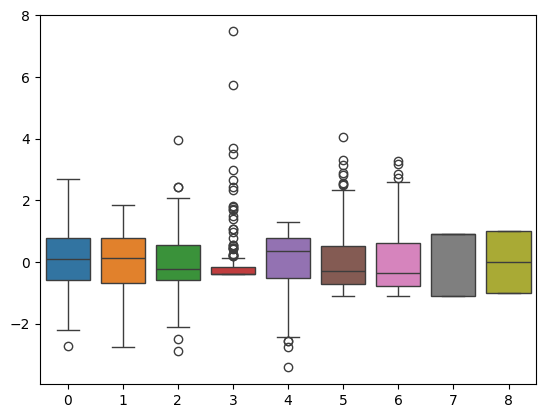

In [ ]:
sns.boxplot(data=X_train)

## Linear Regression

Mean abs error: 0.5439176005762619
R2 score 0.9847407468876919


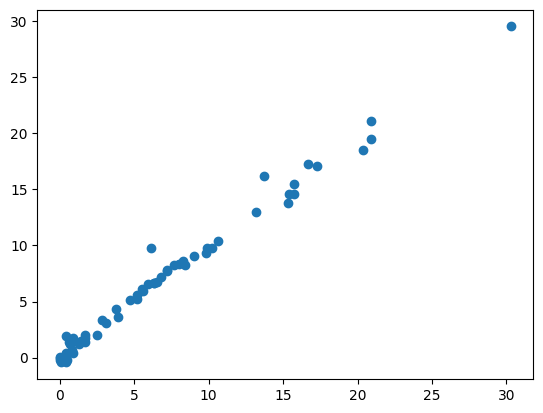

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
model=LinearRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)
mae=mean_absolute_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print("Mean abs error:",mae)
print("R2 score",score)
plt.scatter(Y_test,y_pred)

## Lasso Regression - It remove the feature which are less correlated 

Mean abs error: 1.1331759949144087
R2 score 0.9492020263112388


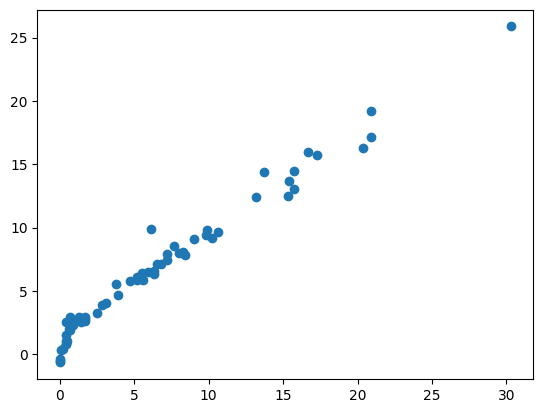

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lassoreg=Lasso()
lassoreg.fit(X_train,Y_train)
y_pred=lassoreg.predict(X_test)
mae=mean_absolute_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print("Mean abs error:",mae)
print("R2 score",score)
plt.scatter(Y_test,y_pred)

## Ridge regression - It decreses the overfittting

Mean abs error: 0.5606469704293074
R2 score 0.9842820919540787


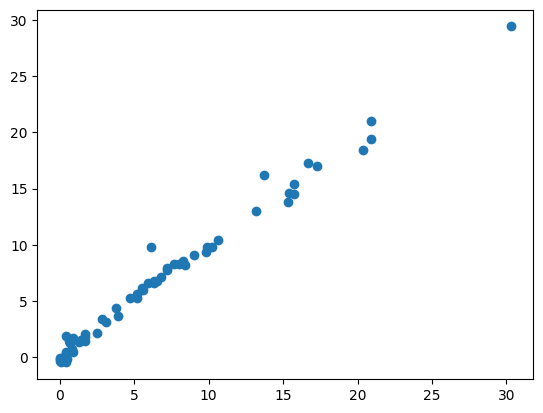

In [21]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
Ridgereg=Ridge()
Ridgereg.fit(X_train,Y_train)
y_pred=Ridgereg.predict(X_test)
mae=mean_absolute_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print("Mean abs error:",mae)
print("R2 score",score)
plt.scatter(Y_test,y_pred)

## ElasticNet - bot ridge and lasso

Mean abs error: 1.8822353634896003
R2 score 0.8753460589519703


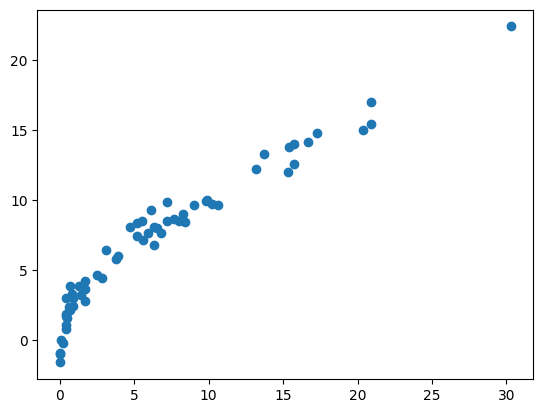

In [22]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
elnreg=ElasticNet()
elnreg.fit(X_train,Y_train)
y_pred=elnreg.predict(X_test)
mae=mean_absolute_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print("Mean abs error:",mae)
print("R2 score",score)
plt.scatter(Y_test,y_pred)

### CrossValidation